<a href="https://colab.research.google.com/github/sanjanabalan84-glitch/ML-AI-PROJECT/blob/main/Day5_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=sns.load_dataset('penguins')
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
df.shape

(344, 7)

In [ ]:
df.size

2408

In [ ]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [ ]:
#highly skewed -log transforms
#outliers,moderate or highly skewed -robust scale

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [ ]:
df.dropna(subset=['bill_length_mm','flipper_length_mm'],inplace=True)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
df.isnull().sum() #df[df].isnull().any(axis=1)] count row with missing

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,9


In [ ]:
df['sex'].value_counts()

,count
sex,
Male,168
Female,165


In [ ]:
df['sex']=df['sex'].fillna(df['sex'].mode()[0])
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                342 non-null    object 
dtypes: float64(4), object(3)
memory usage: 21.4+ KB


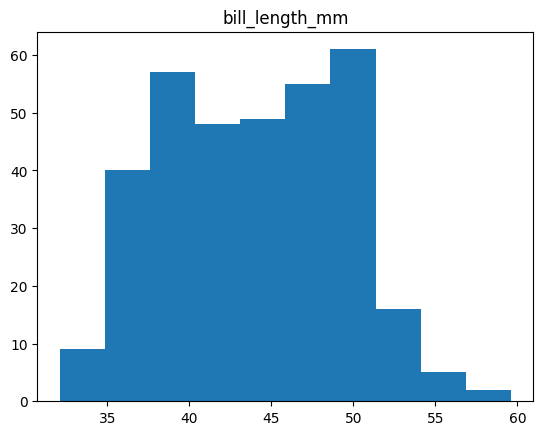

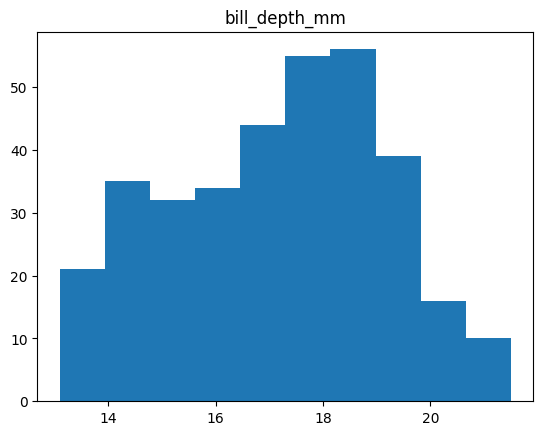

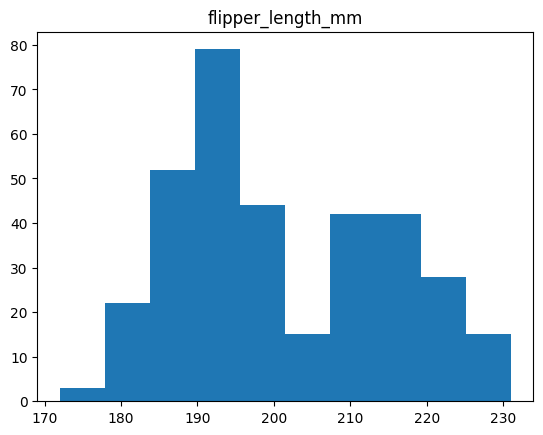

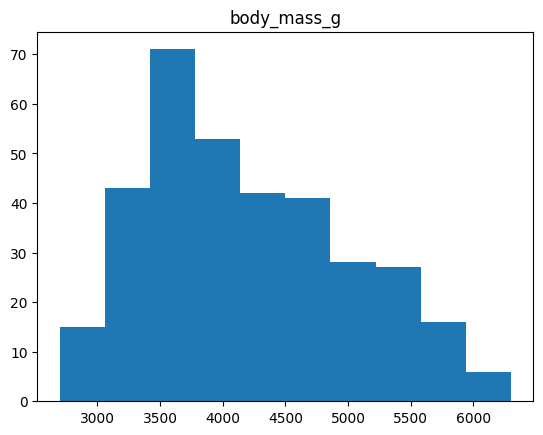

In [ ]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
    plt.hist(df[col])
    plt.title(col)
    plt.show()

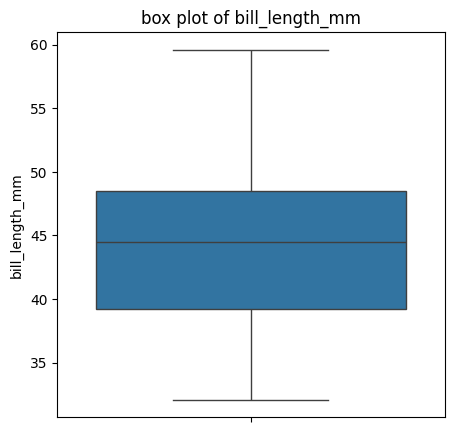

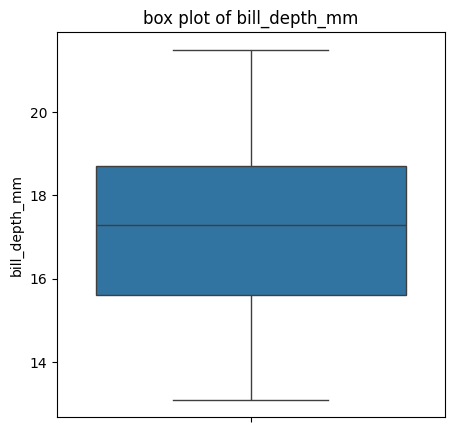

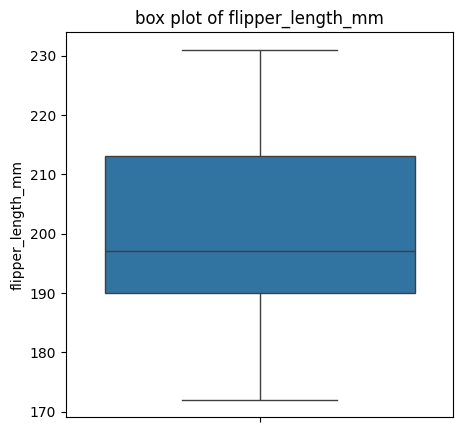

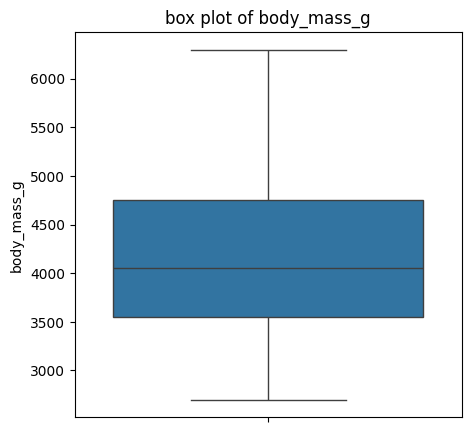

In [ ]:
numerical_cols=df.select_dtypes(include=np.number).columns
for col in numerical_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(y=df[col])
  plt.title(f'box plot of {col}')
  plt.show()

In [ ]:
from scipy.stats import skew

In [ ]:
skew_values=df[numerical_cols].skew() # showing how much skewed is
print(skew_values)

bill_length_mm       0.053118
bill_depth_mm       -0.143465
flipper_length_mm    0.345682
body_mass_g          0.470329
dtype: float64


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['sex']=le.fit_transform(df["sex"])
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,1
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,1
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['island']=le.fit_transform(df["island"])
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,2,39.1,18.7,181.0,3750.0,1
1,Adelie,2,39.5,17.4,186.0,3800.0,0
2,Adelie,2,40.3,18.0,195.0,3250.0,0
4,Adelie,2,36.7,19.3,193.0,3450.0,0
5,Adelie,2,39.3,20.6,190.0,3650.0,1
...,...,...,...,...,...,...,...
338,Gentoo,0,47.2,13.7,214.0,4925.0,0
340,Gentoo,0,46.8,14.3,215.0,4850.0,0
341,Gentoo,0,50.4,15.7,222.0,5750.0,1
342,Gentoo,0,45.2,14.8,212.0,5200.0,0


In [ ]:
df['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [ ]:
from scipy.stats import skew
cat_value=df.select_dtypes(include='object').columns
num_valued=df.select_dtypes(include=["int64","float64"]).columns
skew_value=df[num_valued].skew()
print(skew_value)

bill_length_mm       0.053118
bill_depth_mm       -0.143465
flipper_length_mm    0.345682
body_mass_g          0.470329
sex                 -0.070528
dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
df["flipper_length_mm"]=std.fit_transform(df[["flipper_length_mm"]])
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,2,39.1,18.7,-1.418347,3750.0,1
1,Adelie,2,39.5,17.4,-1.062250,3800.0,0
2,Adelie,2,40.3,18.0,-0.421277,3250.0,0
4,Adelie,2,36.7,19.3,-0.563715,3450.0,0
5,Adelie,2,39.3,20.6,-0.777373,3650.0,1


In [ ]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
df["body_mass_g"]=std.fit_transform(df[["body_mass_g"]])
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,2,39.1,18.7,-1.418347,-0.564142,1
1,Adelie,2,39.5,17.4,-1.062250,-0.501703,0
2,Adelie,2,40.3,18.0,-0.421277,-1.188532,0
4,Adelie,2,36.7,19.3,-0.563715,-0.938776,0
5,Adelie,2,39.3,20.6,-0.777373,-0.689020,1


In [ ]:
y=df['species']
x=df.drop(['species'],axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
x_train.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
25,0,35.3,18.9,-0.991031,-0.501703,0
324,0,47.3,13.8,1.074328,0.653419,1
144,1,37.3,16.8,-0.634935,-1.500727,0
209,1,49.3,19.9,0.148478,-0.189508,1
254,0,49.1,14.8,1.359205,1.184151,0


In [ ]:
x_train.shape

(256, 6)

In [ ]:
x_test.shape

(86, 6)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression()
lr_model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_predict=lr_model.predict(x_test)
y_predict

array(['Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Gentoo',
       'Chinstrap', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie', 'Gentoo',
       'Gentoo', 'Gentoo', 'Adelie', 'Chinstrap', 'Adelie', 'Adelie',
       'Chinstrap', 'Adelie', 'Chinstrap', 'Adelie', 'Gentoo', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Chinstrap', 'Adelie', 'Gentoo',
       'Chinstrap', 'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Adelie',
       'Chinstrap', 'Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Gentoo', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo', 'Gentoo',
       'Adelie', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Chinstrap', 'Adelie', 'Gentoo', 'Gentoo', 'Adelie',
       'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Chinstrap', 'Chinstrap',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Gentoo', 'Gentoo', 'Gentoo', 'Adelie', 'Gentoo', 'Chinstrap',
       'Gentoo', 'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Gentoo',
       'Adelie', 'Ad

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [ ]:
confusion_matrix(y_test,y_predict)

array([[43,  1,  0],
       [ 0, 13,  0],
       [ 0,  0, 29]])

In [ ]:
accuracy=accuracy_score(y_test,y_predict)
accuracy

0.9883720930232558

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model=RandomForestClassifier() #without feature
rf_model.fit(x_train,y_train)
y_predict=rf_model.predict(x_test)
print(accuracy_score(y_test,y_predict))
confusion_matrix(y_test,y_predict)

0.9767441860465116


array([[42,  2,  0],
       [ 0, 13,  0],
       [ 0,  0, 29]])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
metric_k={}
neighbors=np.arange(3,20)
for k in neighbors:
  knn_model=KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=2)
  knn_model.fit(x_train,y_train)
  y_predict=knn_model.predict(x_test)
  acc=accuracy_score(y_test,y_predict)
  metric_k[k]=acc
  metric_k

In [ ]:
metric_k

{np.int64(3): 0.9767441860465116,
 np.int64(4): 0.9767441860465116,
 np.int64(5): 0.9767441860465116,
 np.int64(6): 0.9767441860465116,
 np.int64(7): 0.9767441860465116,
 np.int64(8): 0.9651162790697675,
 np.int64(9): 0.9651162790697675,
 np.int64(10): 0.9651162790697675,
 np.int64(11): 0.9651162790697675,
 np.int64(12): 0.9651162790697675,
 np.int64(13): 0.9651162790697675,
 np.int64(14): 0.9651162790697675,
 np.int64(15): 0.9651162790697675,
 np.int64(16): 0.9534883720930233,
 np.int64(17): 0.9534883720930233,
 np.int64(18): 0.9534883720930233,
 np.int64(19): 0.9534883720930233}

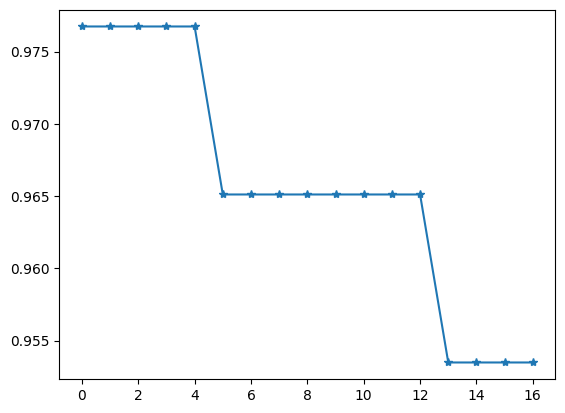

In [ ]:
plt.plot(metric_k.values(),marker="*")


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier()
dt_model.fit(x_train,y_train)
y_pred=dt_model.predict(x_test)
print(accuracy_score(y_test,y_pred))
confusion_matrix(y_test,y_pred)

0.9534883720930233


array([[40,  3,  1],
       [ 0, 13,  0],
       [ 0,  0, 29]])

In [ ]:
#dimonds

In [ ]:
df=sns.load_dataset('diamonds')
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
df.shape

(53940, 10)

In [ ]:
df.size

539400

In [ ]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [ ]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


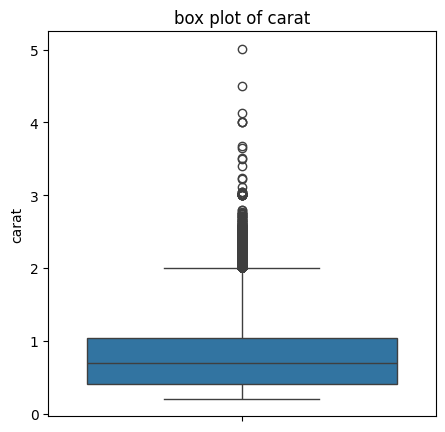

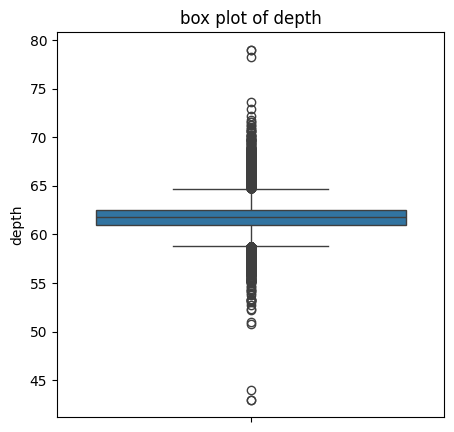

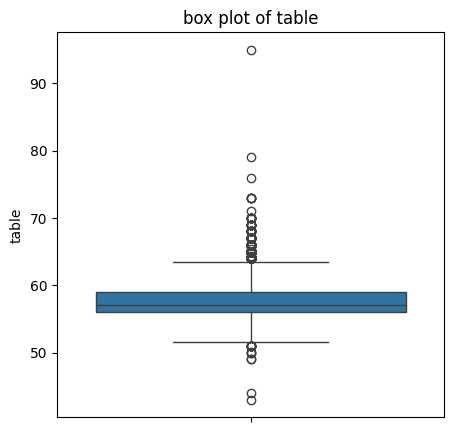

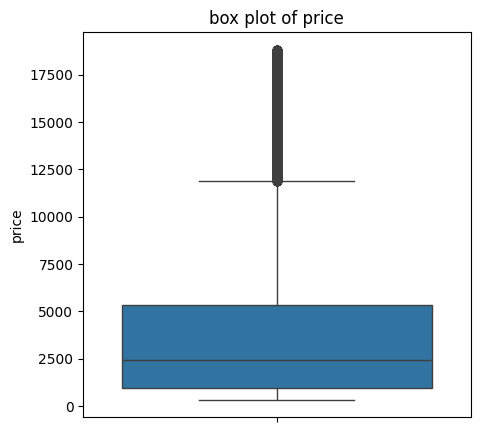

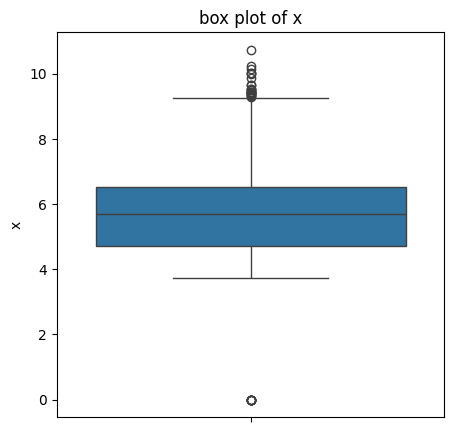

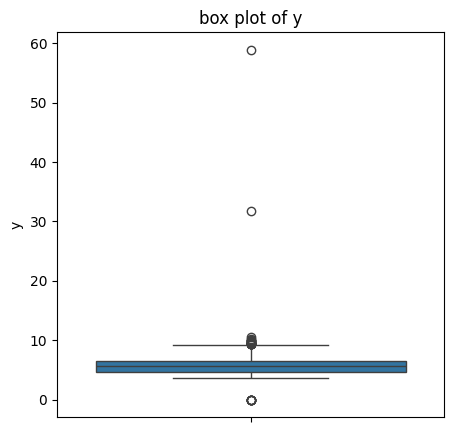

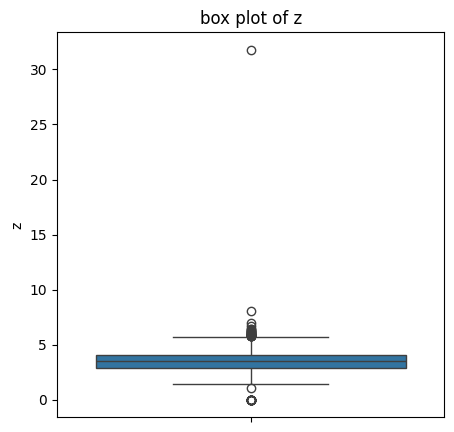

In [ ]:
numerical_cols=df.select_dtypes(include=np.number).columns
for col in numerical_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(y=df[col])
  plt.title(f'box plot of {col}')
  plt.show()

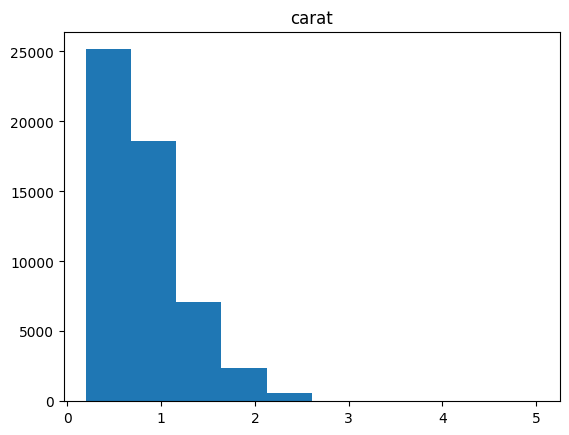

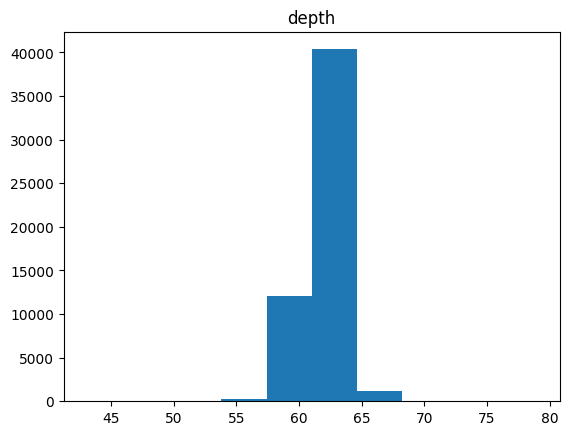

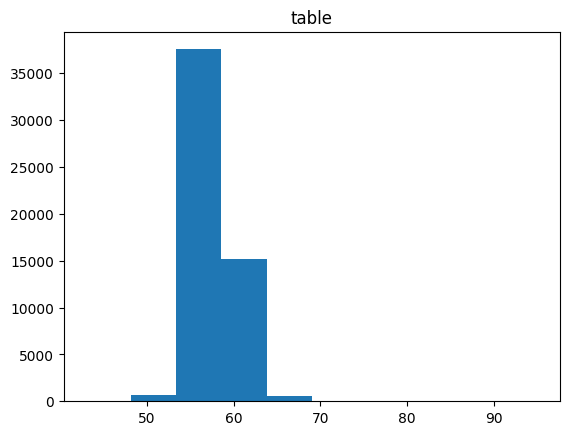

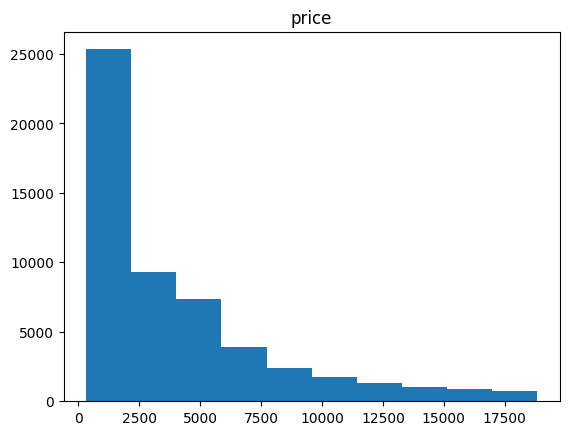

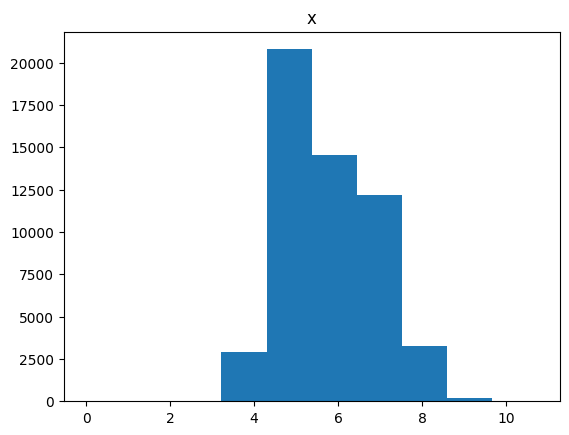

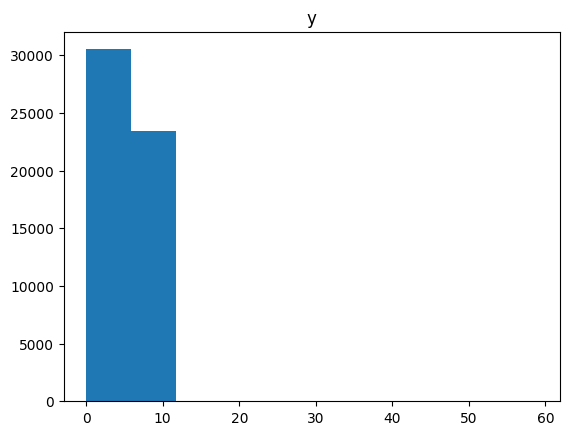

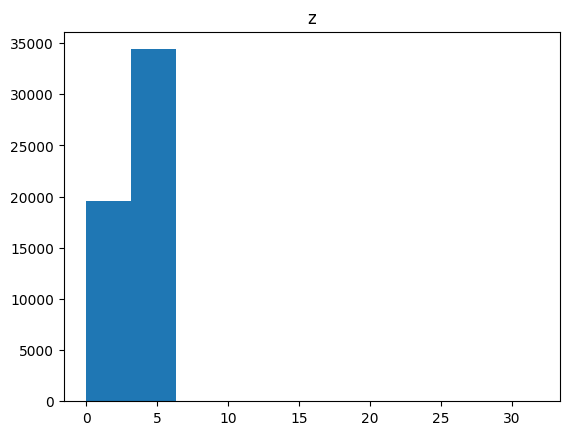

In [ ]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
    plt.hist(df[col])
    plt.title(col)
    plt.show()

In [ ]:
df['cut'].unique()

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']

In [ ]:
df['color'].unique()

['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']

In [ ]:
df['clarity'].unique()

['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

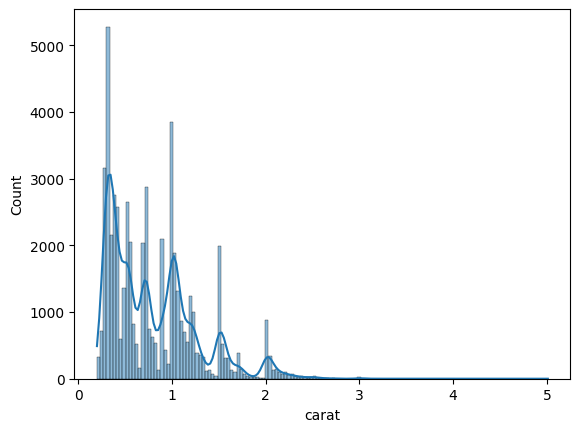

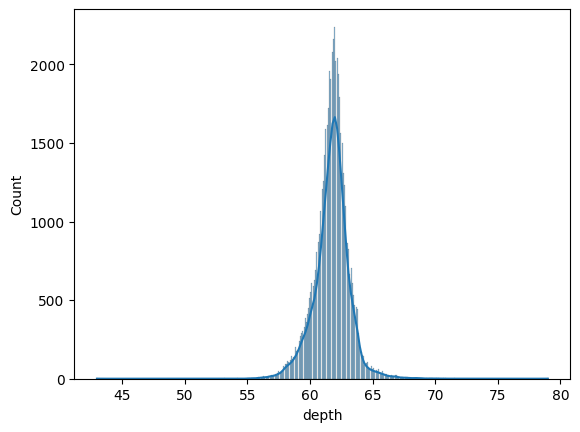

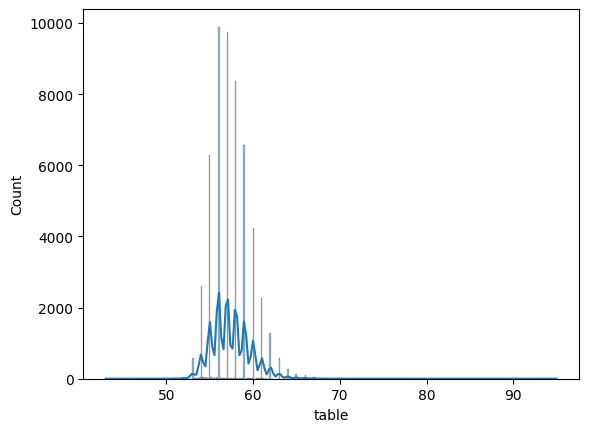

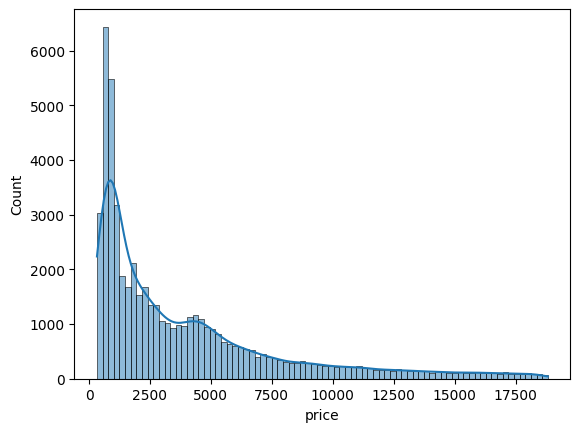

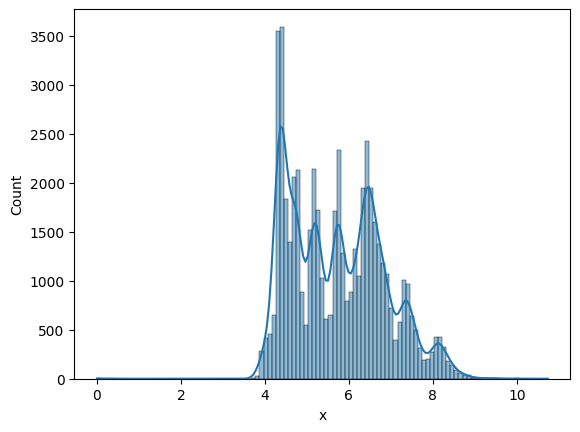

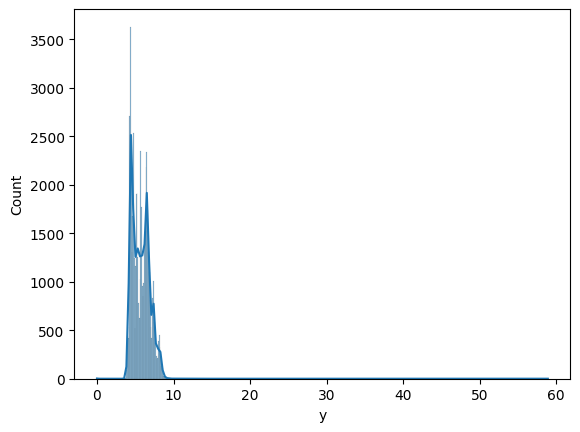

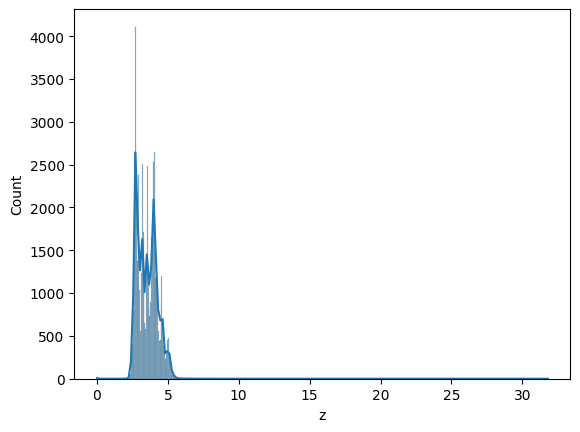

In [ ]:
numerical_cols=df.select_dtypes(include=np.number).columns
for col in numerical_cols:
    sns.histplot(df[col],kde=True)
    plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder
df=pd.get_dummies(df,columns=['cut','color','clarity'],drop_first=True)
df.head()

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,False,False,True,...,False,False,False,False,False,True,False,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,True,False,False,...,False,True,False,False,False,False,True,False,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,False,False,True,...,False,False,True,False,False,False,False,False,True,False


In [ ]:
bool_col=df.select_dtypes(include='bool').columns
df[bool_col]=df[bool_col].astype(int)

In [ ]:
df[bool_col]

,cut_Premium,cut_Very Good,cut_Good,cut_Fair,color_E,color_F,color_G,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0
3,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
4,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
53936,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
53937,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
53938,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0


In [ ]:
from scipy.stats.mstats import winsorize
df['carat']=winsorize(df['carat'],limits=(0,0.05))            #for col in ['carat','depth','table']:
print("outliers in 'carat colunm treated using winsorize")    #    df[col]=winsorize(df[col],limits=(0.05,0.05))
df.head()                                                     #print()

outliers in 'carat colunm treated using winsorize


,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,1,0,0,...,0,1,0,0,0,0,1,0,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,0,0,1,...,0,0,1,0,0,0,0,0,1,0


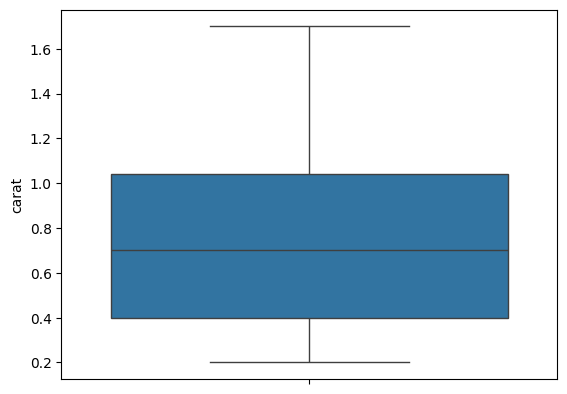

In [ ]:
sns.boxplot(y=df['carat']);


In [ ]:
x_train.head()

,carat,depth,table,x,y,z,cut_Premium,cut_Very Good,cut_Good,cut_Fair,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
35965,-0.956044,2.199202,0.242928,-1.587837,-0.849558,-0.703125,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
52281,0.197802,0.035317,-0.652139,0.275322,0.185841,0.218750,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
6957,0.439560,-0.453303,0.242928,0.738883,0.407080,0.546875,1,0,0,0,...,0,0,1,0,0,0,1,0,0,0
9163,0.434066,-0.732514,-0.652139,0.712140,0.371681,0.500000,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
50598,-0.131868,0.035317,-0.204605,-0.268471,-0.141593,-0.140625,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df[['x','depth','table']]=scaler.fit_transform(df[['x','depth','table']])

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
df[['carat','y','z']]=scaler.fit_transform(df[['y','z','carat']])

In [ ]:
y=df['price']
x=df.drop(columns=['price'])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_model=DecisionTreeRegressor()
dt_model.fit(x_train,y_train)
y_pred=dt_model.predict(x_test)


In [ ]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
print(f'mae:{mean_squared_error(y_test,y_pred)}')
print(f'mse:{mean_squared_error(y_test,y_pred)}')
print(f'r2:{mean_squared_error(y_test,y_pred)}')

mae:552744.699054505
mse:552744.699054505
r2:552744.699054505


In [ ]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)
y_pred=lr_model.predict(x_test)


In [ ]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
print(f'mae:{mean_squared_error(y_test,y_pred)}')
print(f'mse:{mean_squared_error(y_test,y_pred)}')
print(f'r2:{mean_squared_error(y_test,y_pred)}')

mae:1828527.0138584978
mse:1828527.0138584978
r2:1828527.0138584978


In [53]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor()
rf_model.fit(x_train,y_train)
y_pred=lr_model.predict(x_test)


In [54]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
print(f'mae:{mean_squared_error(y_test,y_pred)}')
print(f'mse:{mean_squared_error(y_test,y_pred)}')
print(f'r2:{mean_squared_error(y_test,y_pred)}')

mae:1828527.0138584978
mse:1828527.0138584978
r2:1828527.0138584978
